# **Complex Systems: Final Project**
### Chialvo map:

$$
x_{n+1} = f(x_n, y_n) = x_n^2 exp(y_n - x_n) + k \\
y_{n+1} = g(y_n, x_n) = ay_n - b x_n + c 
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import scienceplots

# Define the style
plt.style.use(['science', 'notebook', 'no-latex']) # Use a specific style for figures

# 1. Mapping Neural Excitability

In [2]:
# Define the Chialvo map functions

def xnext(x, y, k):
    """
    Compute the next x value in the Chialvo map.
    """
    return x**2 * np.exp(y - x) + k

def ynext(y, x, a, b, c):   
    """
    Compute the next y value in the Chialvo map.
    """
    return a * y - b * x + c

In [3]:
# y array
y = np.linspace(-1, 5, 100)

# x array
x = np.linspace(-1, 13, 100)

# Define the parameters
a = 0.89
b = 0.6
c = 0.28
k = 0.0

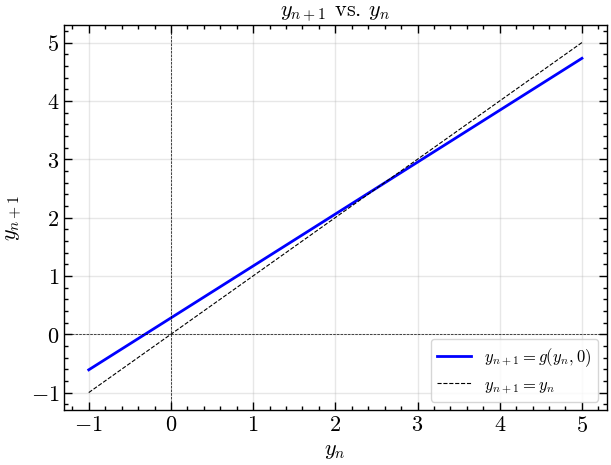

In [4]:
# Plot y_n vs. y_n+1
plt.figure(figsize=(7, 5))
plt.plot(y, ynext(y, 0, a, b, c), label=r'$y_{n+1} = g(y_n, 0)$', color='blue')
plt.plot(y, y, label=r'$y_{n+1} = y_n$', color='black', ls='--', lw=0.8)
plt.title(r'$y_{n+1}$ vs. $y_n$')
plt.xlabel(r'$y_n$')
plt.ylabel(r'$y_{n+1}$')
plt.axhline(0, color='black', lw=0.5, ls='--')
plt.axvline(0, color='black', lw=0.5, ls='--')
plt.grid(alpha=0.3)
plt.legend(frameon=True, fontsize=12)
plt.show()

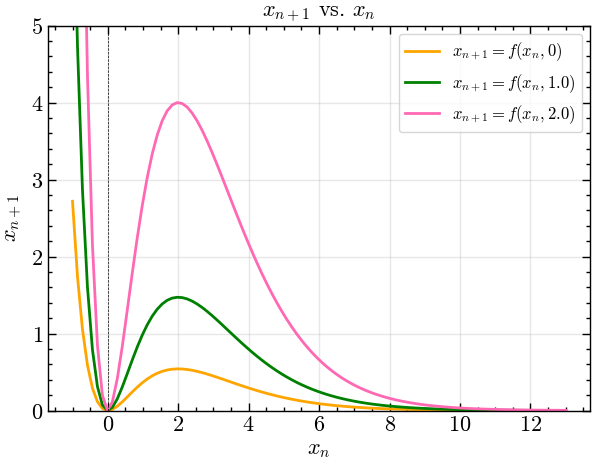

In [5]:
# Plot y_n vs. y_n+1
plt.figure(figsize=(7, 5))
plt.plot(x, xnext(x, 0, k), label=r'$x_{n+1} = f(x_n, 0)$', color='orange')
plt.plot(x, xnext(x, 1.0, k), label=r'$x_{n+1} = f(x_n, 1.0)$', color='green')
plt.plot(x, xnext(x, 2.0, k), label=r'$x_{n+1} = f(x_n, 2.0)$', color='hotpink')
plt.title(r'$x_{n+1}$ vs. $x_n$')
plt.xlabel(r'$x_n$')
plt.ylabel(r'$x_{n+1}$')
plt.ylim(0, 5)
plt.axhline(0, color='black', lw=0.5, ls='--')
plt.axvline(0, color='black', lw=0.5, ls='--')
plt.grid(alpha=0.3)
plt.legend(frameon=True, fontsize=12)
plt.show()

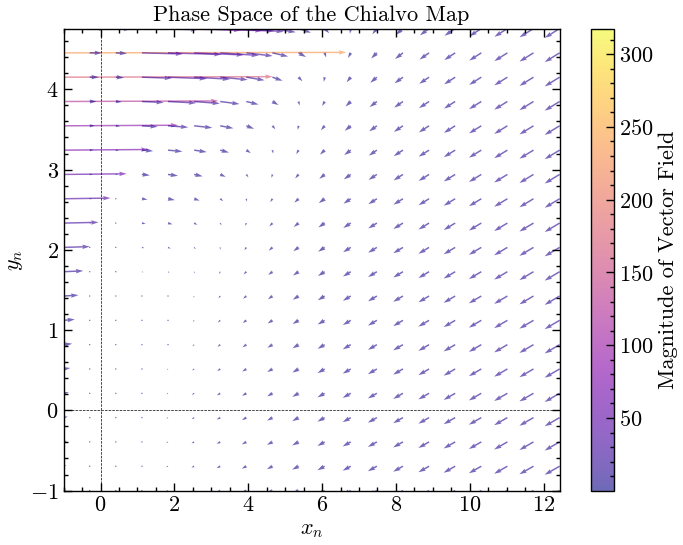

In [6]:
X, Y = np.meshgrid(x, y)
U = xnext(X, Y, k) - X
V = ynext(Y, X, a, b, c) - Y
# Compute module of vectors
magnitude = np.sqrt(U**2 + V**2)


# Interpolate for better visualization
fac_reduction = 5
new_x = x[::fac_reduction]
new_y = y[::fac_reduction]
grid_x, grid_y = np.meshgrid(new_x, new_y)
U_interp = griddata((X.flatten(), Y.flatten()), U.flatten(), (grid_x, grid_y), method='cubic')
V_interp = griddata((X.flatten(), Y.flatten()), V.flatten(), (grid_x, grid_y), method='cubic')
magnitude = np.sqrt(U_interp**2 + V_interp**2)

plt.figure(figsize=(8, 6))
plt.quiver(grid_x, grid_y, U_interp, V_interp, magnitude, cmap='plasma', alpha=0.6)
plt.title('Phase Space of the Chialvo Map')
plt.xlabel(r'$x_n$')
plt.ylabel(r'$y_n$')
plt.xlim(new_x.min(), new_x.max())
plt.ylim(new_y.min(), new_y.max())
plt.colorbar(label='Magnitude of Vector Field')
plt.axhline(0, color='black', lw=0.5, ls='--')
plt.axvline(0, color='black', lw=0.5, ls='--')
#plt.grid(alpha=0.3)
plt.show()

### Bifurcation diagram

$y$ is virtually frozen ($x=0$), then:

$$
y_{f0} = r= \frac{c}{1-a},
$$

A perturbation in x is essentially described by the iteration map:

$$
x_{n+1} = x_n^2exp(r - x_n)
$$


In [7]:
# Bifurcation diagram for x_n

def xnext_bifurcation(x, r):
    return x**2 * np.exp(r - x)

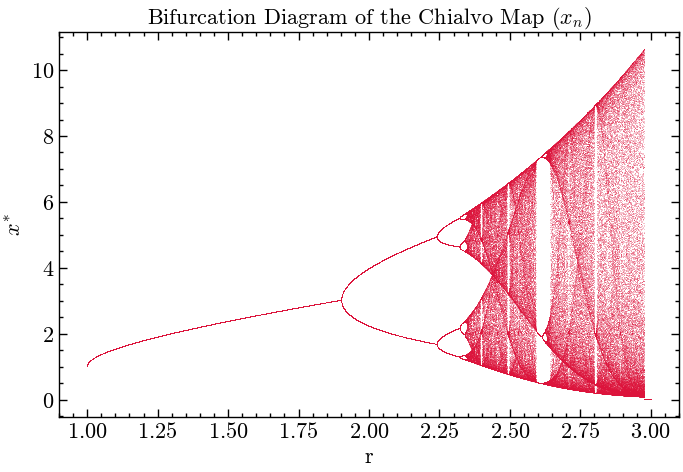

In [8]:
# Define n 
n = 5000

# Define r range
r = np.linspace(1.0, 3., n)

# Define initial x_n
x_n = 1.2 * np.ones(n)

# Define iterations and last
iterations = 1000
last = 100

plt.figure(figsize=(8, 5))
for i in range(iterations):
    x_n = xnext_bifurcation(x_n, r)
    if i >= (iterations - last):
        plt.plot(r, x_n, alpha=0.25, color='crimson', marker=',', linestyle='None')

plt.title(r'Bifurcation Diagram of the Chialvo Map ($x_n$)')
plt.xlabel('r')
plt.ylabel(r'$x^{*}$')
plt.show()

Let's analize the case $k=0$. Then, the equations

$$
x_{n+1} = f(x_n, y_n) = x_n^2 exp(y_n - x_n) + k \\
y_{n+1} = g(y_n, x_n) = ay_n - b x_n + c 
$$

can be written as: (...)




In [9]:
class ChialvoMap:
    def __init__(self, a=0.89, b=0.6, c=0.28, k=0.025, T=1000):
        self.a = a
        self.b = b
        self.c = c
        self.k = k
        self.T = T
        self.trajectory = np.zeros((self.T, 2))

    def step(self):
        x_new = self.x**2 * np.exp(self.y - self.x) + self.k
        y_new = self.a * self.y - self.b * self.x + self.c
        self.x, self.y = x_new, y_new

        return [self.x, self.y]

    def run(self, x0=0.0, y0=0.0):     
        self.x, self.y = x0, y0

        for t in range(self.T):
            self.trajectory[t] = self.step()

        return np.array(self.trajectory)

    def plot_trajectory(self):
        plt.plot(self.trajectory[:, 0], self.trajectory[:, 1])
        plt.xlabel('x')
        plt.ylabel('y')
        plt.title('Chialvo Map Trajectory')
        plt.grid(alpha=0.3)
        plt.show()

In [10]:
chialvo = ChialvoMap(T=50, a = 0.89, b = 0.6, c = 0.28, k = 0.02)
trajectory = chialvo.run(x0=0.09, y0=2.54)

In [11]:
# Nullclines and fixed points
def nullcline_x(x, k=0.02):
    y = np.log((x - k) / (x**2)) + x
    return y

def nullcline_y(x, a = 0.89, b = 0.6, c = 0.28):
    y = (c - b * x) / (1 - a)
    return y

/tmp/ipykernel_51330/2971092805.py:3: RuntimeWarning: invalid value encountered in log
  y = np.log((x - k) / (x**2)) + x


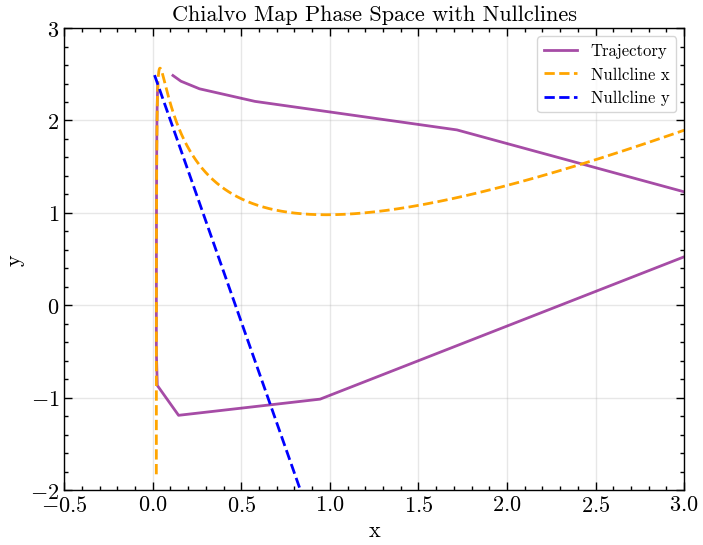

In [12]:
# Phase space with nullclines
x_null = np.linspace(0.01, 5, 60000)
nclinex = nullcline_x(x_null)
ncliney = nullcline_y(x_null)

plt.figure(figsize=(8, 6))
plt.plot(trajectory[:, 0], trajectory[:, 1], label='Trajectory', color='purple', alpha=0.7)
plt.plot(x_null, nclinex, label='Nullcline x', color='orange', ls='--')
plt.plot(x_null, ncliney, label='Nullcline y', color='blue', ls='--')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Chialvo Map Phase Space with Nullclines')
plt.xlim(-0.5, 3.0)
plt.ylim(-2, 3)
plt.grid(alpha=0.3)
plt.legend(frameon=True, fontsize=12)
plt.show()

This plot reveals the mechanism behind the action potential. It's not just a pulse in time; it's a structured loop in state space, driven by the interplay between the fast activation variable ($x$) and the slow recovery variable ($y$). The N-shaped X-nullcline is the classic feature of excitable systems that enables this behavior.

**Nullclide:** The focus of point with null derivatives for each state variable. 

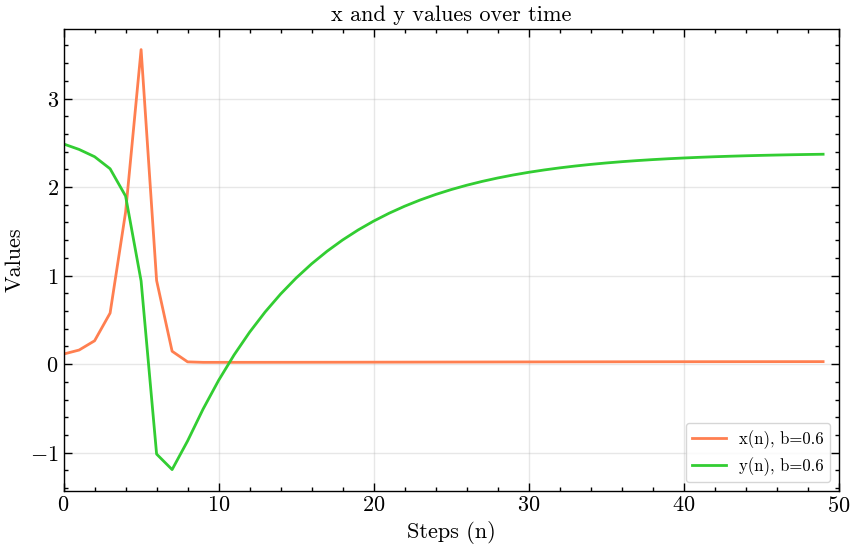

In [13]:
# plot steps vs. x and y values
fig = plt.figure(figsize=(10, 6))

b_val = np.linspace(0.2, 0.8, 1000)

# Color gradient for values of b
colors_1 = plt.cm.viridis(np.linspace(0, 1, len(b_val)))
colors_2 = plt.cm.plasma(np.linspace(0, 1, len(b_val)))
colors = np.vstack((colors_1, colors_2)) 

# for i, b in enumerate(b_val):
#     chialvo_plot = ChialvoMap(T=100, a = 0.89, b = b, c = 0.28, k = 0.02)
#     trajectory = chialvo_plot.run(x0=0.09, y0=2.54)
#     plt.plot(trajectory[:, 0], color=colors_1[i])
#     plt.plot(trajectory[:, 1], color=colors_2[i])

# b = 0.6 highlight
plt.plot(trajectory[:, 0], color='coral', linewidth=2, label=f'x(n), b={0.6}')
plt.plot(trajectory[:, 1], color='limegreen', linewidth=2, label=f'y(n), b={0.6}')  
plt.title('x and y values over time')
#Add colorbar
# sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=b_val.min(), vmax=b_val.max()))
# sm.set_array([])
# cbar = plt.colorbar(sm, ax=plt.gca())
# cbar.set_label('b values')
plt.legend(frameon=True, fontsize=12, loc ='lower right')
plt.xlim(0, 50)
plt.xlabel('Steps (n)')
plt.ylabel('Values')
plt.grid(alpha=0.3)
plt.show()

I already show that $x_f=0$ is a fixed point, so we set the IC of the y (recovery) variable to its fixed value and we vary a litle bit x to see how the system evolves.
This example is very good to exlain this system because there we saw how the x variable respresents the action potential (like a neuron's spike). The variable that decreases and then slowly recovers is the recovery variable.

Notice lso the effect of the parameter $b$ which controls how strongly $x_n$ drives $y_n$ down. 

FInally, the recovery happes a rate of a. Just take a look to the equations and you will see it.

# 2. Phase Plane and Qualitative Solutions

X-nullclide:

$$
y = ln(x-k) - 2 ln(x) + x,
$$

Y-nullclide:

$$
x = \frac{(a-1)y + c}{b}
$$

In [14]:
# Phase space with nullclines
x_for_nullX = np.linspace(-0.0201, 5, 100000)
x_for_nullY = np.linspace(-0.2, 5, 100000)
dx = nullcline_x(x_for_nullX, k=0.02)
dy = nullcline_y(x_for_nullY, a=0.89, b=0.6, c=0.28)

/tmp/ipykernel_51330/2971092805.py:3: RuntimeWarning: invalid value encountered in log
  y = np.log((x - k) / (x**2)) + x


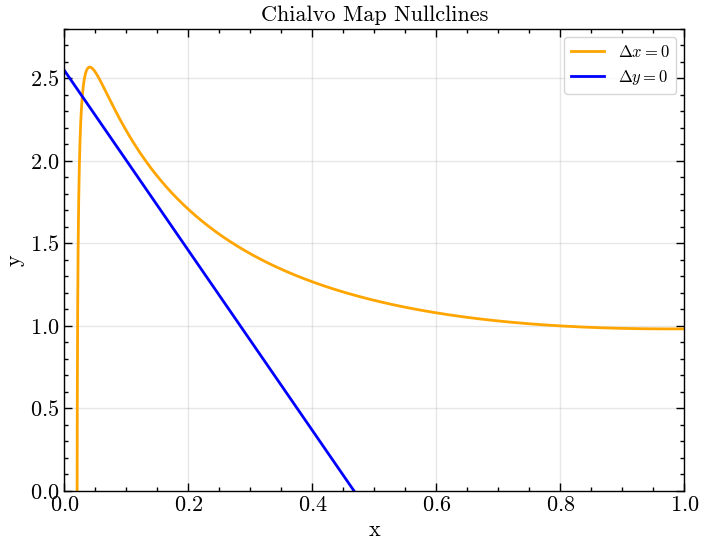

In [15]:
# Plot nullclines
plt.figure(figsize=(8, 6))
plt.plot(x_for_nullX, dx, label=r'$\Delta x = 0$', color='orange')
plt.plot(x_for_nullY, dy, label=r'$\Delta y = 0$', color='blue')
plt.title('Chialvo Map Nullclines')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(0., 1.)
plt.ylim(0, 2.8)
plt.legend(frameon=True, fontsize=12)
plt.grid(alpha=0.3)
plt.show()


/tmp/ipykernel_51330/2971092805.py:3: RuntimeWarning: invalid value encountered in log
  y = np.log((x - k) / (x**2)) + x


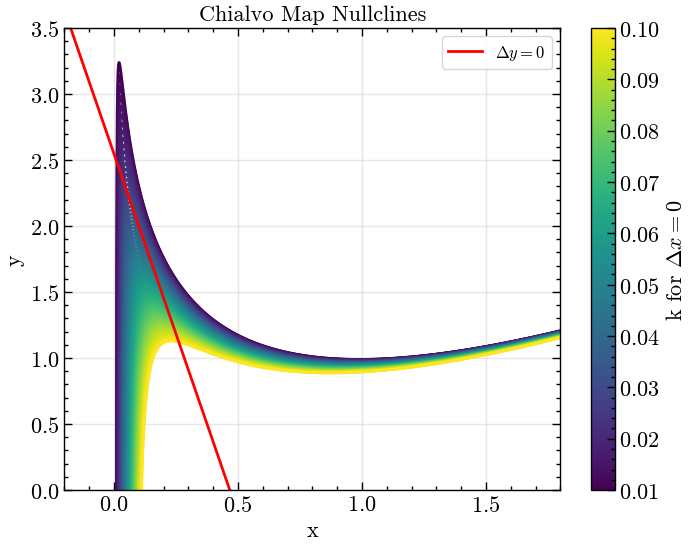

In [16]:
# Plot nullclines
plt.figure(figsize=(8, 6))

# Define k values
k_values = np.arange(0.01, 0.1, 0.001)
# k_values = [0.01, 0.04, 0.08, 0.1]

# cmap for k 
cmap = plt.get_cmap('viridis')
colors = cmap(np.linspace(0, 1, len(k_values)))

for k, color in zip(k_values, colors):
    dx = nullcline_x(x_for_nullX, k=k)
    plt.plot(x_for_nullX, dx, color=color)
plt.plot(x_for_nullY, dy, label=r'$\Delta y = 0$', color='red')

plt.title('Chialvo Map Nullclines')
plt.xlabel('x')
plt.ylabel('y')

plt.xlim(-0.2, 1.8)
plt.ylim(0.0, 3.5)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=k_values.min(), vmax=k_values.max()))
sm.set_array([])
plt.colorbar(sm, label='k for ' + r'$\Delta x = 0$' , ax=plt.gca())

plt.legend(frameon=True, fontsize=12)
plt.grid(alpha=0.3)
plt.show()

Parameters for nullclides with three intersections:

In [17]:
# Phase space with nullclines
x_for_nullX = np.linspace(-0.0201, 5, 100000)
x_for_nullY = np.linspace(-0.2, 5, 100000)
dx = nullcline_x(x_for_nullX, k=0.02)
dy = nullcline_y(x_for_nullY, a=0.89, b=0.3, c=0.26)

/tmp/ipykernel_51330/2971092805.py:3: RuntimeWarning: invalid value encountered in log
  y = np.log((x - k) / (x**2)) + x


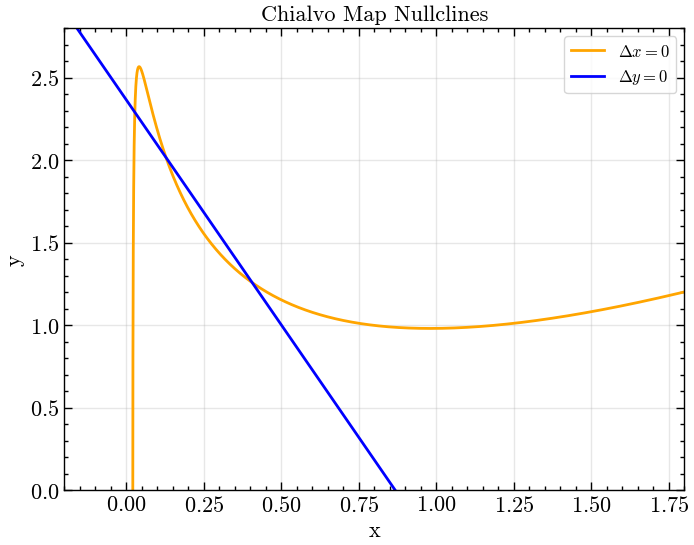

In [18]:
# Plot nullclines
plt.figure(figsize=(8, 6))
plt.plot(x_for_nullX, dx, label=r'$\Delta x = 0$', color='orange')
plt.plot(x_for_nullY, dy, label=r'$\Delta y = 0$', color='blue')
plt.title('Chialvo Map Nullclines')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-0.2, 1.8)
plt.ylim(0, 2.8)
plt.legend(frameon=True, fontsize=12)
plt.grid(alpha=0.3)
plt.show()


## 2.1 Non-autonomous solutions: excitable dynamics

Increasing $k$ in this model can be equivalent to a bias current applied to a nerve cell that progressively depolarizes its membrane potential.

Why nullcline are important?

- The system rests at the nullclines' intersections and may response to a proper perturbation with an action potential.

- The quiescent-excitable regime will exist as long as nullclines intersect to the left of the
X-nullcline maxima.

- It is seen that increasing $k$ decreases the negative slope of the X-nullcline, which (for other parameters fixed) shifts the nullclines’ intersection towards conditions where the fixed point loses stability and oscillatory solutions appears.

### 2.1.1 Normal and supernormal excitability




In [38]:
# Phase space with nullclines
x_for_nullX = np.linspace(-0.0201, 1., 100000)
x_for_nullY = np.linspace(0, 1., 100000)
dx = nullcline_x(x_for_nullX, k=0.02)
dy = nullcline_y(x_for_nullY, a=0.89, b=0.6, c=0.28)

# Intersection points
from scipy.optimize import fsolve
def equations(p):
    # Define parameters
    k = 0.02
    a = 0.89
    b = 0.6
    c = 0.28

    x, y = p
    return (np.log(x-k) - 2 * np.log(x) + x - y,
            (y*(a-1)+c)/(b) - x) 

initial_guesses = [(0.03, 2.39)]

fixed_points = []
for guess in initial_guesses:
    fixed_point = fsolve(equations, guess)
    fixed_points.append(fixed_point)   

/tmp/ipykernel_51330/2971092805.py:3: RuntimeWarning: invalid value encountered in log
  y = np.log((x - k) / (x**2)) + x


In [39]:
print("Fixed Points (x, y):")
for point in fixed_points:
    print(point)

Fixed Points (x, y):
[0.0287569  2.38859872]


/tmp/ipykernel_51330/1743237734.py:6: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  plt.plot(point[0], point[1], 'ro', label='Fixed Point', color='red', zorder=5)


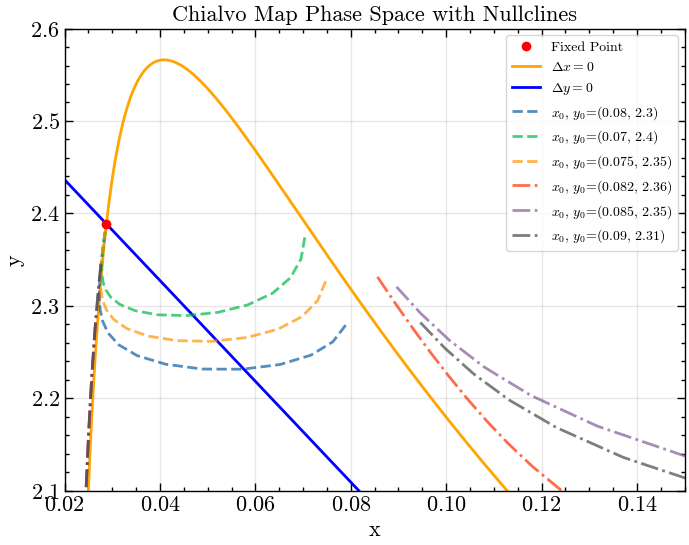

In [44]:
# Plot nullclines
plt.figure(figsize=(8, 6))

# Plot fixed points
for point in fixed_points:
    plt.plot(point[0], point[1], 'ro', label='Fixed Point', color='red', zorder=5)

# Plot nullclines
plt.plot(x_for_nullX, dx, label=r'$\Delta x = 0$', color='orange')
plt.plot(x_for_nullY, dy, label=r'$\Delta y = 0$', color='blue')

# Phase space for diffrent initial conditions
ics_st = [(0.08, 2.3), (0.07, 2.4), (0.075, 2.35)] # superthreshold
ics_ap = [(0.082, 2.36), (0.085, 2.35), (0.09, 2.31)] # action potential

for ic in ics_st:
    chialvo = ChialvoMap(T=50, a = 0.89, b = 0.6, c = 0.28, k = 0.02)
    trajectory = chialvo.run(x0=ic[0], y0=ic[1])
    plt.plot(trajectory[:, 0], trajectory[:, 1], linestyle='--',
             label=r'$x_{0}, \, y_{0}$=' + f'{ic}', alpha=0.7)
    
for ic in ics_ap:
    chialvo = ChialvoMap(T=50, a = 0.89, b = 0.6, c = 0.28, k = 0.02)
    trajectory = chialvo.run(x0=ic[0], y0=ic[1])
    plt.plot(trajectory[:, 0], trajectory[:, 1], linestyle='-.',
             label=r'$x_{0}, \, y_{0}$=' + f'{ic}', alpha=0.7)

plt.title('Chialvo Map Phase Space with Nullclines')
plt.xlabel('x')
plt.ylabel('y')
plt.ylim(2.10, 2.6)
plt.xlim(0.02, 0.15)
plt.legend(frameon=True, fontsize=10)
plt.grid(alpha=0.3)
plt.show()